In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("FancyFollicles.csv")

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.367541e+09,2596,i.imgur.com,1dl5y2,And now my hair is on fire!!,disconinja127,4503,1907,130,http://www.reddit.com/r/FancyFollicles/comment...,NaN,NaN,False,http://d.thumbs.redditmedia.com/xMfYwsaF_n9p_-...,t5_2sa9a,False,NaN,purple,False,t3_1dl5y2,http://i.imgur.com/74drZsy.jpg,NaN
1,1.364067e+09,2496,i.imgur.com,1avg04,Single father of 6 Year old- first results. Th...,LiesAboutKnowingYou,4210,1714,74,http://www.reddit.com/r/FancyFollicles/comment...,NaN,NaN,False,http://a.thumbs.redditmedia.com/K2CeqnANMwnOyE...,t5_2sa9a,False,NaN,NaN,False,t3_1avg04,http://i.imgur.com/iDwj9ij.jpg,NaN
2,1.373606e+09,2265,i.imgur.com,1i4veb,I love women who aren't afraid to step outside...,WoopAhhh,4346,2081,111,http://www.reddit.com/r/FancyFollicles/comment...,NaN,NaN,False,http://e.thumbs.redditmedia.com/6qBXnpexFoXk6Z...,t5_2sa9a,False,NaN,NaN,False,t3_1i4veb,http://i.imgur.com/3FClx5e.jpg,NaN
3,1.353981e+09,2135,imgur.com,13uik9,I knew I was going to lose my hair to chemo. D...,square--one,2994,859,76,http://www.reddit.com/r/FancyFollicles/comment...,NaN,NaN,False,http://d.thumbs.redditmedia.com/v_E3ol-FfArd3d...,t5_2sa9a,False,NaN,NaN,False,t3_13uik9,http://imgur.com/a/H6nCW,NaN
4,1.375670e+09,2100,i.imgur.com,1jpsia,"After 6 hours of twisting, my arms were dead b...",morgandonor,3931,1831,79,http://www.reddit.com/r/FancyFollicles/comment...,NaN,NaN,False,http://f.thumbs.redditmedia.com/tLLRtKpV19Ahvt...,t5_2sa9a,False,NaN,NaN,False,t3_1jpsia,http://i.imgur.com/eukvj5Q.png,NaN


In [4]:
label_encoders = {}

for column in df.select_dtypes(include='string').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [6]:
[col for col in df.columns if "churn" in col.lower()]

[]

In [7]:
df.columns = df.columns.str.strip()

In [8]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [11]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



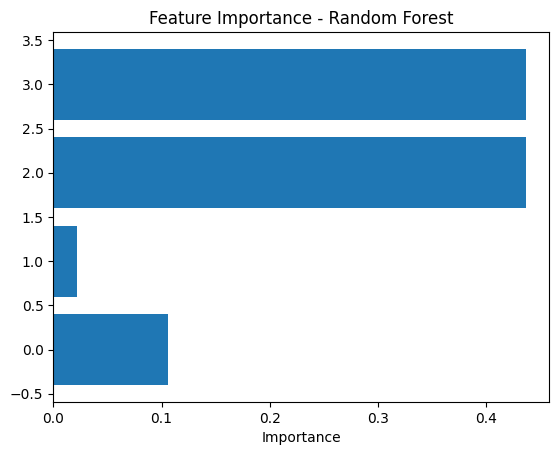

In [16]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

importances = rf_model.feature_importances_

# Handle both cases
if hasattr(X, "columns"):
    features = X.columns
else:
    features = range(len(importances))

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()